# 3.1.4 Ejercicios: componente gigante, clustering y regímenes en grafos de Erdős–Rényi

Ana Luisa Llamas Martinez

ENES-Juriquilla

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import random
from scipy.stats import binom, poisson
import numpy as np
from scipy.stats import binom, poisson

def grafo_erdos_renyi(N, p, seed=None):
    """
    Genera una realización del grafo aleatorio G(N,p).
    """
    if seed is not None:
        random.seed(seed)

    G = nx.Graph()
    G.add_nodes_from(range(N))

    for i in range(N):
        for j in range(i + 1, N):
            if random.random() < p:
                G.add_edge(i, j)

    return G

def dibujar_realizaciones(N, p, n_realizaciones=3, layout="spring", seed_base=10):
    """
    Dibuja varias realizaciones de G(N,p) con los mismos parámetros.
    """
    fig, axes = plt.subplots(1, n_realizaciones, figsize=(5 * n_realizaciones, 5))

    if n_realizaciones == 1:
        axes = [axes]

    for k, ax in enumerate(axes):
        G = grafo_erdos_renyi(N, p, seed=seed_base + k)

        # Elegir layout
        if layout == "circular":
            pos = nx.circular_layout(G)
        else:
            pos = nx.spring_layout(G, seed=seed_base + k)

        L = G.number_of_edges()

        nx.draw_networkx_nodes(
            G, pos, ax=ax,
            node_size=300,
            node_color="#7a4fa3"
        )
        nx.draw_networkx_edges(
            G, pos, ax=ax,
            edge_color="limegreen",
            width=1.5
        )

        ax.set_title(f"Realización {k+1}\nN={N}, p={p}, L={L}", fontsize=12)
        ax.set_axis_off()

    plt.tight_layout()
    plt.show()

def dibujar_realizaciones_con_esperanza(N, p, n_realizaciones=3, layout="spring", seed_base=10):
    """
    Dibuja varias realizaciones de G(N,p) con los mismos parámetros.
    """
    fig, axes = plt.subplots(1, n_realizaciones, figsize=(5 * n_realizaciones, 5))

    if n_realizaciones == 1:
        axes = [axes]
    L_esperado = p * N * (N-1) / 2
    for k, ax in enumerate(axes):
        G = grafo_erdos_renyi(N, p, seed=seed_base + k)

        # Elegir layout
        if layout == "circular":
            pos = nx.circular_layout(G)
        else:
            pos = nx.spring_layout(G, seed=seed_base + k)

        L = G.number_of_edges()

        nx.draw_networkx_nodes(
            G, pos, ax=ax,
            node_size=300,
            node_color="#7a4fa3"
        )
        nx.draw_networkx_edges(
            G, pos, ax=ax,
            edge_color="limegreen",
            width=1.5
        )

        ax.set_title(f"Realización {k+1}\nN={N}, p={p}, L={L}\nE[L]={L_esperado:.2f}", fontsize=12)
        ax.set_axis_off()

    plt.tight_layout()
    plt.show()

def simular_numero_aristas(N, p, n_sim=1000):
    valores_L = []
    for s in range(n_sim):
        G = grafo_erdos_renyi(N,p, seed=s)
        valores_L.append(G.number_of_edges())

    return valores_L

## Ejercicio 1. Componentes conexas al variar la probabilidad de conexión.

Fije N = 100 y considere los valores p = 0.001, 0.005, 0.01, 0.02, 0.03, 0.05.

Para cada valor de p:
- Genere una realización del grafo aleatorio G(N, p).
- Calcule el número de componentes conexas.
- Calcule el tamaño de la componente conexa más grande.
- Dibuje la red obtenida.
- Organice los resultados en una tabla.

El número de componentes conexas es 95 y el tamaño de la componente conexa más grande es 3


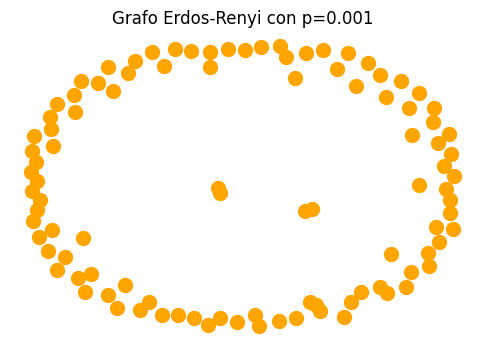

El número de componentes conexas es 76 y el tamaño de la componente conexa más grande es 5


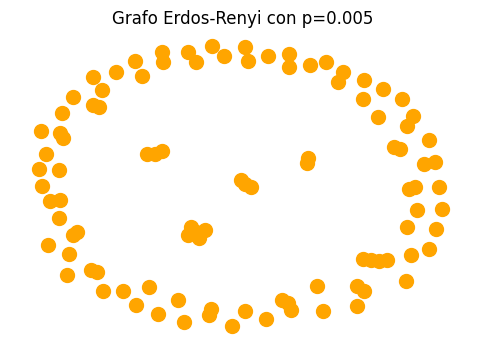

El número de componentes conexas es 49 y el tamaño de la componente conexa más grande es 24


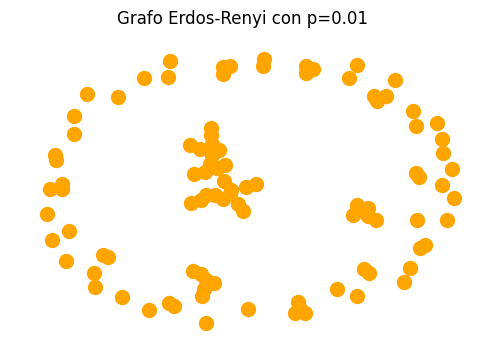

El número de componentes conexas es 12 y el tamaño de la componente conexa más grande es 87


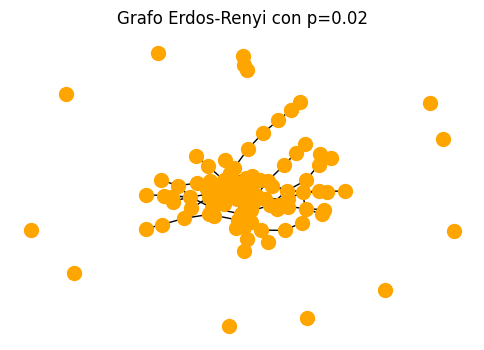

El número de componentes conexas es 4 y el tamaño de la componente conexa más grande es 97


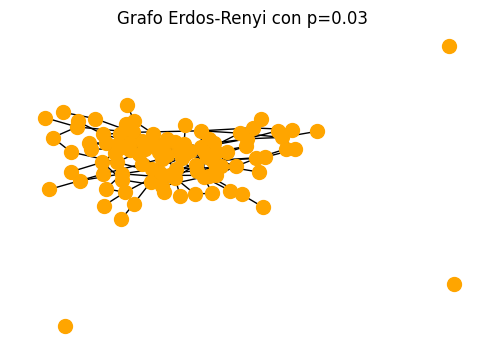

El número de componentes conexas es 2 y el tamaño de la componente conexa más grande es 99


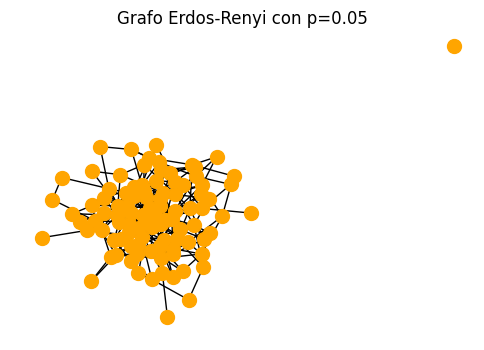

In [11]:
N1 = 100
p1 = [0.001, 0.005, 0.01, 0.02, 0.03, 0.05]

for i in p1:
    G = grafo_erdos_renyi(N1, i, seed=None)

    comp_conexas = list(nx.connected_components(G))

    no_comp = len(comp_conexas)

    comp_max = len(max(comp_conexas, key=len))

    print(f"El número de componentes conexas es {no_comp} y el tamaño de la componente conexa más grande es {comp_max}")
    
    plt.figure(figsize=(6, 4))
    plt.title(f"Grafo Erdos-Renyi con p={i}")
    nx.draw(G, node_size=100, node_color='orange')
    plt.show()


**Pregunta conceptual.**

¿Cómo cambia la estructura de la red al aumentar p? ¿En qué rango parece emerger una componente gigante?

**R=** Al aumentar p, la red empieza a aumentar su conectividad, como formando componentes y aumentando el tamaño de la mayor de ellas. En nuestro ejemplo, parece dicha componente aparece en el rango 0.03 y 0.05

## Ejercicio 2. Tamaño relativo de la componente gigante

Fije N = 200 y considere valores de p en el intervalo [0.001, 0.03].

- Para cada valor de p, genere una realización del grafo aleatorio $G(N, p)$.
- Calcule el tamaño de la componente conexa más grande, denotado por $S_{max}$.
- Calcule la fracción
    $$\frac{S_{max}}{N}$$
- Grafique $\frac{S_{max}}{N}$ en función de p.

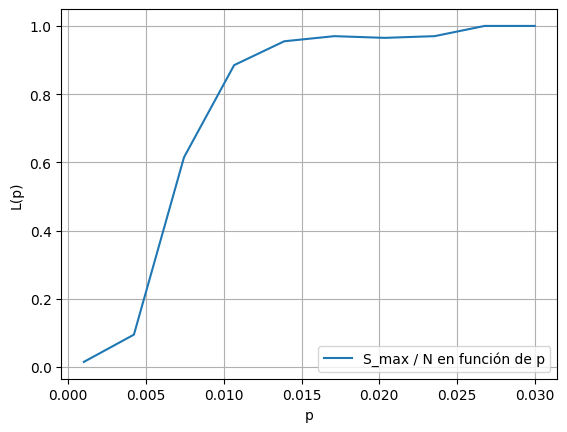

In [3]:
N2 = 200
p2 = np.linspace(0.001, 0.03, 10)

V = []

for i in p2:
    G = grafo_erdos_renyi(N2, i, seed=None)
    S_max = len(max(nx.connected_components(G), key=len))

    v = S_max / N2

    V.append(v)

plt.plot(p2, V, label="S_max / N en función de p")
plt.xlabel("p")
plt.ylabel("L(p)")
plt.legend()
plt.grid(True)
plt.show()

**Pregunta conceptual.**

¿En qué rango de valores de p comienza a crecer rápidamente la componente más grande?

**R=** Dada la gráfica, parece que la componente más grande empieza a crecer rápidamente en el rango entre 0.005 y 0.010. Después de ahí, se empieza a estancar el crecimiento.

## Ejercicio 3. Aparición de la componente gigante y grado promedio.

Fije N=200 y considere los valores

$$ p = \frac{0.5}{N-1} , \frac{1}{N-1} , \frac{1.5}{N-1} , \frac{2}{N-1} , \frac{3}{N-1}$$

Para cada valor de p:

- Calcule el grado promedio esperado ⟨k⟩=p(N−1).
- Genere una realización del grafo.
- Calcule el tamaño de la componente conexa más grande.
- Compare los resultados obtenidos.

In [4]:
N3 = 200
p3 = [0.5/(N3-1), 1/(N3-1), 1.5/(N3-1), 2/(N3-1), 3/(N3-1)]

grados3 = []
componentes3 = []

for i in p3:
    grado_prom_esp = i * (N3-1)
    G = grafo_erdos_renyi(N3, i, seed=None)
    S_max = len(max(nx.connected_components(G), key=len))

    grados3.append(grado_prom_esp)
    componentes3.append(S_max)

print("Lista de grados promedios:", grados3)
print("Lista de tamaños de las componentes conexas más grandes:", componentes3)
    

Lista de grados promedios: [0.5, 1.0, 1.5, 2.0, 3.0]
Lista de tamaños de las componentes conexas más grandes: [5, 15, 137, 166, 189]


**Pregunta conceptual.**

¿Qué relación observa entre la aparición de una componente gigante y el valor del grado promedio esperado?

**R=** Cuando el grado promedio es igual o menor a 1, el tamaño de la componente es pequeña comparada al tamaño total de la red. Sin embargo, una vez superado ese umbral, se dispara el tamaño de la componente conexa máxima, casi llegando a cubrir en su totalidad la red.


## Ejercicio 4. Coeficiente de clustering en una realización.

Considere un grafo aleatorio G(N,p) con N=100 y p=0.05.

- Genere una realización del grafo.
- Calcule el coeficiente de clustering local de cada nodo.
- Calcule el coeficiente de clustering promedio de la red.
- Compare el valor observado con el valor teórico esperado C≈p.

In [6]:
N4 = 100
p4 = 0.05

G4 = grafo_erdos_renyi(N4, p4, seed=None)

print("El coeficiente de clustering local de cada nodo es:", dict(nx.clustering(G4)))

El coeficiente de clustering local de cada nodo es: {0: 0, 1: 0, 2: 0.16666666666666666, 3: 0, 4: 0, 5: 0.3333333333333333, 6: 0, 7: 0, 8: 0, 9: 0, 10: 0, 11: 0, 12: 0, 13: 0.09523809523809523, 14: 0, 15: 0, 16: 0, 17: 0, 18: 0, 19: 0, 20: 0.1, 21: 0, 22: 0.3333333333333333, 23: 0.14285714285714285, 24: 0, 25: 0.022222222222222223, 26: 0, 27: 0.16666666666666666, 28: 0, 29: 0.13333333333333333, 30: 0, 31: 0, 32: 0.3333333333333333, 33: 0.1, 34: 0.16666666666666666, 35: 0.07142857142857142, 36: 0, 37: 0, 38: 0, 39: 0.1, 40: 0.13333333333333333, 41: 0, 42: 0, 43: 0, 44: 0, 45: 0, 46: 0, 47: 0, 48: 0.047619047619047616, 49: 0, 50: 0, 51: 0.03571428571428571, 52: 0.06666666666666667, 53: 0, 54: 0.1, 55: 0, 56: 0.047619047619047616, 57: 0, 58: 0, 59: 0, 60: 0.1, 61: 0.16666666666666666, 62: 0.047619047619047616, 63: 0, 64: 0, 65: 0.1, 66: 0.16666666666666666, 67: 0, 68: 0.3333333333333333, 69: 0, 70: 0, 71: 0, 72: 0.1, 73: 0, 74: 0, 75: 0.08333333333333333, 76: 0, 77: 0.1, 78: 0, 79: 0, 80:

In [7]:
print("El coeficiente de clustering promedio es:", nx.average_clustering(G4))

El coeficiente de clustering promedio es: 0.05417460317460317


In [8]:
dif = p4 - nx.average_clustering(G4)

print("La diferencia entre el clustering teórico y el observado fue", dif)

La diferencia entre el clustering teórico y el observado fue -0.004174603174603164


**Pregunta conceptual.**

¿Por qué en el modelo de Erdős–Rényi el coeficiente de clustering esperado es aproximadamente igual a p?

**R=** Porque en E-R la formación de cada arista tiene una probabilidad fija $p$. En cambio, el coeficiente de clustering local de un nodo es la probabilidad de que dos de sus vecinos estén conectados entre sí y, en este caso, es el mismo para todos.

## Ejercicio 5. Clustering promedio al variar p

Fije N=100 y considere valores de p en el intervalo [0.01, 0.20].

- Para cada valor de p, genere una realización del grafo aleatorio G(N,p).
- Calcule el coeficiente de clustering promedio observado.
- Grafique el clustering promedio observado en función de p.
- Compare con la recta teórica C=p.

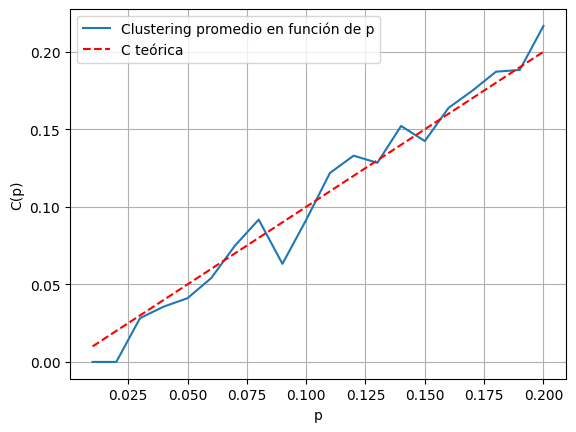

In [13]:
N5 = 100
p5 = np.linspace(0.01, 0.20, 20)

clust_prom = []

for i in p5:
    G = grafo_erdos_renyi(N5, i, seed=None)
    c = nx.average_clustering(G)
    clust_prom.append(c)

plt.plot(p5, clust_prom, label="Clustering promedio en función de p")
plt.plot(p5, p5, label="C teórica", linestyle="--", color="red")
plt.xlabel("p")
plt.ylabel("C(p)")
plt.legend()
plt.grid(True)
plt.show()

**Pregunta conceptual.**

¿Cómo depende el clustering promedio del parámetro p?

**R=** Ignorando un poco el ruido, podemos decir que la dependencia es lineal y proporcional.

## Ejercicio 6. Componente gigante y clustering.

Fije N= 200 y considere valores de p en un intervalo que incluya el umbral de aparición de la componente gigante.

Para cada valor de p:

- Genere una realización de G(N,p).
- Calcule:
    - el tamaño relativo de la componente más grande $\frac{S_{max}}{N}$,
    - el coeficiente de clustering promedio C.
- Grafique ambas cantidades en función de p.

In [17]:
import math 
N6 = 200
umbral = math.log(N6) / N6
p6 = np.linspace(umbral - umbral/2, umbral + umbral/2, 100)

S_max6 = []
clust_prom6 = []

for i in p6:
    G = grafo_erdos_renyi(N6, i, seed=None)

    c = nx.average_clustering(G)
    clust_prom6.append(c)

    s = len(max(nx.connected_components(G), key=len))/N6
    S_max6.append(s)


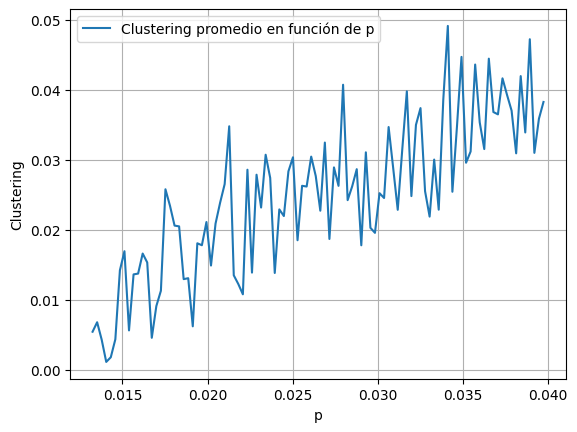

In [21]:
plt.plot(p6, clust_prom6, label="Clustering promedio en función de p")
plt.xlabel("p")
plt.ylabel("Clustering")
plt.legend()
plt.grid(True)
plt.show()

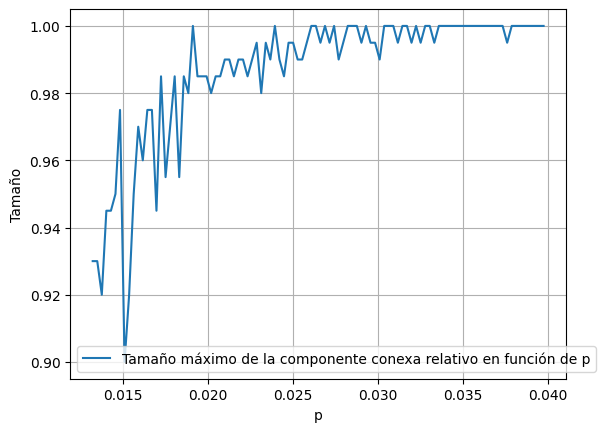

In [19]:
plt.plot(p6, S_max6, label="Tamaño máximo de la componente conexa relativo en función de p")
plt.xlabel("p")
plt.ylabel("Tamaño")
plt.legend()
plt.grid(True)
plt.show()

**Pregunta conceptual.**

¿Qué diferencia hay entre una propiedad global, como el tamaño de la componente gigante, y una propiedad local, como el clustering?

**R=** En el caso del clustering, solo nos enfocamos en los vecinos de un nodo. En nuestro gráfico podemos ver que varia demasiado, dado que cada es algo muy específico de la realización. Por otra parte, el tamaño de la componente gigante es bastante sensible, aunque rápido se estabiliza porque porque estamos considerando toda la estructura, la cual es bastante homogénea.

## Ejercicio 7. Conectividad total de la red.

Fije N=100 y considere valores de p cercanos a

$$\frac{log N}{N}.$$

- Calcule el valor aproximado de $\frac{logN}{N}$.
- Elija varios valores de p por debajo y por encima de ese umbral.
- Para cada valor de p, genere varias realizaciones del grafo.
- Determine en cada caso si el grafo es conexo o no.
- Estime la proporción de grafos conexos para cada valor de p.
- Grafique esa proporción en función de p.

In [23]:
import math

N7 = 100

valor = math.log(N7) / N7

print("El valor aproximado es:", valor)

El valor aproximado es: 0.04605170185988092


In [26]:
p7 = np.linspace(0.01, 0.05, 50)
proporcion = []

for i in p7:
    grafos_conexos = 0
    for j in range(0, 200):
        G = grafo_erdos_renyi(N7, i, seed=None)
        
        if nx.is_connected(G):
            grafos_conexos += 1
            
    p = grafos_conexos / 200
    proporcion.append(p)

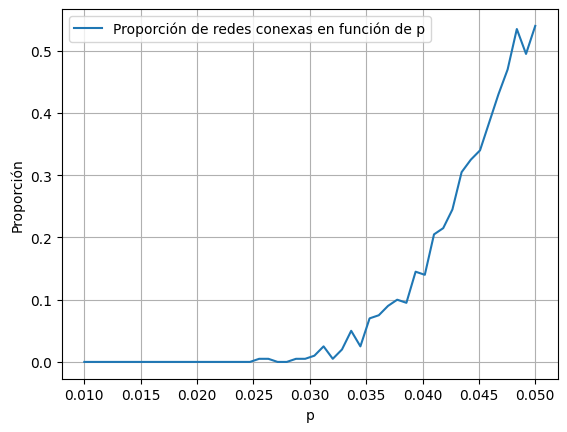

In [27]:
plt.plot(p7, proporcion, label="Proporción de redes conexas en función de p")
plt.xlabel("p")
plt.ylabel("Proporción")
plt.legend()
plt.grid(True)
plt.show()

**Pregunta conceptual.**

¿Cuál es la diferencia entre que exista una componente gigante y que toda la red sea conexa?

**R=** Sus umbrales son diferentes. Aparece antes una componente gigante.